In [ ]:
from IPython.display import display
import sympy as sp
from sympy.printing.mathml import mathml

In [ ]:
#Mendefinisikan Parameter dan Kompartemen yang Terlibat
S, E, I, R, u1, u2, u3, u4, u5 = sp.symbols("S, E, I, R, u1, u2, u3, u4, u5", cls = sp.Function)
LAMBDA, beta, mu, epsilon, gamma, phi = sp.symbols("Lambda, beta, mu, epsilon, gamma, phi")
A1, A2, B1, B2, B3, B4, B5, t, J = sp.symbols("A1, A2, B1, B2, B3, B4, B5 t, J")

t0 = 0
tf = 90

#Pendefinisian Fungsi Objektif
def obj():
  return A1*E(t) + A2*I(t) + (1/2)*B1*(u1(t)**2) + (1/2)*B2*(u2(t)**2) + (1/2)*B3*(u3(t)**2) + (1/2)*B4*(u4(t)**2) + (1/2)*B5*(u5(t)**2)
def dS():
  return LAMBDA - beta*S(t)*I(t) - mu*S(t) - u1(t)*S(t)
def dE():
  return beta*S(t)*I(t) - (epsilon + mu + phi + u2(t) + u3(t))*E(t)
def dI():
  return (epsilon + u2(t) + u3(t))*E(t) - (gamma + mu + phi + u4(t) + u5(t))*I(t)
def dR():
  return (gamma + u4(t) + u5(t))*I(t) + u1(t)*S(t) - mu*R(t)

display(sp.Eq(J, sp.Integral(obj(), (t, t0, tf))))
display(sp.Eq(S(t).diff(t), dS()))
display(sp.Eq(E(t).diff(t), dE()))
display(sp.Eq(I(t).diff(t), dI()))
display(sp.Eq(R(t).diff(t), dR()))

Eq(J, Integral(A1*E(t) + A2*I(t) + 0.5*B1*u1(t)**2 + 0.5*B2*u2(t)**2 + 0.5*B3*u3(t)**2 + 0.5*B4*u4(t)**2 + 0.5*B5*u5(t)**2, (t, 0, 90)))

Eq(Derivative(S(t), t), Lambda - beta*I(t)*S(t) - mu*S(t) - S(t)*u1(t))

Eq(Derivative(E(t), t), beta*I(t)*S(t) - (epsilon + mu + phi + u2(t) + u3(t))*E(t))

Eq(Derivative(I(t), t), (epsilon + u2(t) + u3(t))*E(t) - (gamma + mu + phi + u4(t) + u5(t))*I(t))

Eq(Derivative(R(t), t), -mu*R(t) + (gamma + u4(t) + u5(t))*I(t) + S(t)*u1(t))

In [ ]:
#Membuat Fungsi Hamiltonian
L1, L2, L3, L4, Hamiltonian = sp.symbols("L1, L2, L3, L4, H", cls = sp.Function)
L1diff, L2diff, L3diff, L4diff = sp.symbols("Ldot_1, Ldot_2, Ldot_3, Ldot_4")
display(sp.Eq(Hamiltonian(t), obj() + L1(t)*dS() + L2(t)*dE() + L3(t)*dI() + L4(t)*dR()))

Hamiltonian = obj() + L1(t)*dS() + L2(t)*dE() + L3(t)*dI() + L4(t)*dR()

Eq(H(t), A1*E(t) + A2*I(t) + 0.5*B1*u1(t)**2 + 0.5*B2*u2(t)**2 + 0.5*B3*u3(t)**2 + 0.5*B4*u4(t)**2 + 0.5*B5*u5(t)**2 + ((epsilon + u2(t) + u3(t))*E(t) - (gamma + mu + phi + u4(t) + u5(t))*I(t))*L3(t) + (beta*I(t)*S(t) - (epsilon + mu + phi + u2(t) + u3(t))*E(t))*L2(t) + (-mu*R(t) + (gamma + u4(t) + u5(t))*I(t) + S(t)*u1(t))*L4(t) + (Lambda - beta*I(t)*S(t) - mu*S(t) - S(t)*u1(t))*L1(t))

In [ ]:
#Persamaan Adjoin
display(sp.Eq(L1diff, -1*sp.diff(Hamiltonian, S(t))))
L1diff = -1*sp.diff(Hamiltonian, S(t))
display(sp.Eq(L2diff, -1*sp.diff(Hamiltonian, E(t))))
L2diff = -1*sp.diff(Hamiltonian, E(t))
display(sp.Eq(L3diff, -1*sp.diff(Hamiltonian, I(t))))
L3diff = -1*sp.diff(Hamiltonian, I(t))
display(sp.Eq(L4diff, -1*sp.diff(Hamiltonian, R(t))))
L4diff = -1*sp.diff(Hamiltonian, R(t))

Eq(Ldot_1, -beta*I(t)*L2(t) - (-beta*I(t) - mu - u1(t))*L1(t) - L4(t)*u1(t))

Eq(Ldot_2, -A1 - (epsilon + u2(t) + u3(t))*L3(t) - (-epsilon - mu - phi - u2(t) - u3(t))*L2(t))

Eq(Ldot_3, -A2 + beta*L1(t)*S(t) - beta*L2(t)*S(t) - (gamma + u4(t) + u5(t))*L4(t) - (-gamma - mu - phi - u4(t) - u5(t))*L3(t))

Eq(Ldot_4, mu*L4(t))

In [ ]:
#Printing Persamaan Adjoin
print(L1diff)
print(L2diff)
print(L3diff)
print(L4diff)

-beta*I(t)*L2(t) - (-beta*I(t) - mu - u1(t))*L1(t) - L4(t)*u1(t)
-A1 - (epsilon + u2(t) + u3(t))*L3(t) - (-epsilon - mu - phi - u2(t) - u3(t))*L2(t)
-A2 + beta*L1(t)*S(t) - beta*L2(t)*S(t) - (gamma + u4(t) + u5(t))*L4(t) - (-gamma - mu - phi - u4(t) - u5(t))*L3(t)
mu*L4(t)


In [ ]:
display(sp.diff(sp.diff(Hamiltonian,u1(t)),u1(t)))
display(sp.diff(sp.diff(Hamiltonian,u2(t)),u2(t)))
display(sp.diff(sp.diff(Hamiltonian,u3(t)),u3(t)))
display(sp.diff(sp.diff(Hamiltonian,u4(t)),u4(t)))
display(sp.diff(sp.diff(Hamiltonian,u5(t)),u5(t)))

1.0*B1

1.0*B2

1.0*B3

1.0*B4

1.0*B5

In [ ]:
display(sp.diff(Hamiltonian,u1(t)))
display(sp.diff(Hamiltonian,u2(t)))
display(sp.diff(Hamiltonian,u3(t)))
display(sp.diff(Hamiltonian,u4(t)))
display(sp.diff(Hamiltonian,u5(t)))

1.0*B1*u1(t) - L1(t)*S(t) + L4(t)*S(t)

1.0*B2*u2(t) - E(t)*L2(t) + E(t)*L3(t)

1.0*B3*u3(t) - E(t)*L2(t) + E(t)*L3(t)

1.0*B4*u4(t) - I(t)*L3(t) + I(t)*L4(t)

1.0*B5*u5(t) - I(t)*L3(t) + I(t)*L4(t)

In [ ]:
display(sp.Eq(u1(t), sp.solve(sp.diff(Hamiltonian,u1(t)),u1(t))[0]))
display(sp.Eq(u2(t), sp.solve(sp.diff(Hamiltonian,u2(t)),u2(t))[0]))
display(sp.Eq(u3(t), sp.solve(sp.diff(Hamiltonian,u3(t)),u3(t))[0]))
display(sp.Eq(u4(t), sp.solve(sp.diff(Hamiltonian,u4(t)),u4(t))[0]))
display(sp.Eq(u5(t), sp.solve(sp.diff(Hamiltonian,u5(t)),u5(t))[0]))

Eq(u1(t), (L1(t) - L4(t))*S(t)/B1)

Eq(u2(t), (L2(t) - L3(t))*E(t)/B2)

Eq(u3(t), (L2(t) - L3(t))*E(t)/B3)

Eq(u4(t), (L3(t) - L4(t))*I(t)/B4)

Eq(u5(t), (L3(t) - L4(t))*I(t)/B5)

In [ ]:
print(sp.solve(sp.diff(Hamiltonian,u1(t)),u1(t))[0])
print(sp.solve(sp.diff(Hamiltonian,u2(t)),u2(t))[0])
print(sp.solve(sp.diff(Hamiltonian,u3(t)),u3(t))[0])
print(sp.solve(sp.diff(Hamiltonian,u4(t)),u4(t))[0])
print(sp.solve(sp.diff(Hamiltonian,u5(t)),u5(t))[0])

(L1(t) - L4(t))*S(t)/B1
(L2(t) - L3(t))*E(t)/B2
(L2(t) - L3(t))*E(t)/B3
(L3(t) - L4(t))*I(t)/B4
(L3(t) - L4(t))*I(t)/B5


Solusi Numerik Tanpa Kontrol

In [ ]:
import sys
sys.modules[__name__].__dict__.clear()
from scipy.integrate import odeint, RK45, solve_ivp #ODE Solver
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
#Model Parameter
# LAMBDA, beta, mu, epsilon, gamma, phi
beta = 0.027
mu = 0.05
LAMBDA = 0.00314
epsilon = 0.0304
gamma = 0.025
phi = 0.031

InitS = 800
InitE = 100
InitI = 100
InitR = 1

#Nilai Bobot Kontrol
A1 = 1
A2 = 1
B1 = 1
B2 = 1
B3 = 1
B4 = 1
B5 = 1

#Set up fOR Forward-Backward Sweep Method
test = -1 #Test variable; as long as variable is negative the while loops keeps repeating
t0 = 0 #Initial time
tf = 90 #Final time
deltaa = 0.00001 #Accepted tollerance
M = (10*tf)-1 #Number of nodes
t = np.linspace(t0,tf,M+1) #Time variable where linspace creates M+1 equally spaced nodes between t0 and tf, including t0 and tf.
h = tf/M #Spacing between nodes
h2 = h/2;

In [ ]:
#Kondisi Awal Model
S = np.zeros((1, M+1), dtype = float)[0]
E = np.zeros((1, M+1), dtype = float)[0]
I = np.zeros((1, M+1), dtype = float)[0]
R = np.zeros((1, M+1), dtype = float)[0]

S[0] = InitS
E[0] = InitE
I[0] = InitI
R[0] = InitR

loopcnt = 0 #Menghitung Jumlah Looping
for lp in range (M):

  oldS = S;
  oldE = E;
  oldI = I;
  oldR = R;

  #Model
  for i in range (0,M):

    m11 = LAMBDA - beta*S[i]*I[i] - mu*S[i]
    m12 = beta*S[i]*I[i] - (epsilon + mu + phi)*E[i]
    m13 = epsilon*E[i] - (gamma + mu + phi)*I[i]
    m14 = gamma*I[i] - mu*R[i]

    S[i+1] = S[i] + h*m11
    E[i+1] = E[i] + h*m12
    I[i+1] = I[i] + h*m13
    R[i+1] = R[i] + h*m14

  S0 = S
  E0 = E
  I0 = I
  R0 = R

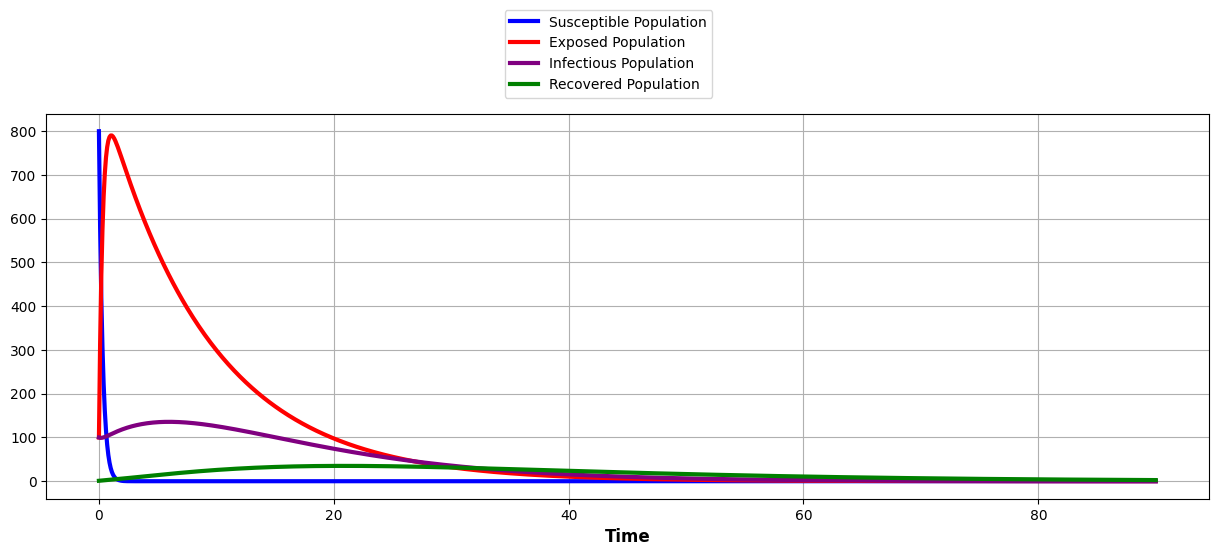

In [ ]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize = (15,5))
plt.plot(t, S0, color = 'blue', ls = '-', label = 'Susceptible Population', linewidth = 3)
plt.plot(t, E0, color = 'red', ls = '-', label = 'Exposed Population', linewidth = 3)
plt.plot(t, I0, color = 'purple', ls = '-', label = 'Infectious Population', linewidth = 3)
plt.plot(t, R0, color = 'green', ls = '-', label = 'Recovered Population', linewidth = 3)
plt.xlabel('Time', fontweight = 'bold', fontsize=12)
plt.legend(bbox_to_anchor=(0.5, 1), loc='center', bbox_transform=plt.gcf().transFigure)
plt.grid()
plt.show()

Solusi Numerik Dengan Kontrol

In [ ]:
#Kondisi Awal Model
S = np.zeros((1, M+1), dtype = float)[0]
E = np.zeros((1, M+1), dtype = float)[0]
I = np.zeros((1, M+1), dtype = float)[0]
R = np.zeros((1, M+1), dtype = float)[0]

S[0] = InitS
E[0] = InitE
I[0] = InitI
R[0] = InitR

#Kondisi Awal Input Kontrol Optimal
u1 = np.zeros((1, M+1), dtype = float)[0]
u2 = np.zeros((1, M+1), dtype = float)[0]
u3 = np.zeros((1, M+1), dtype = float)[0]
u4 = np.zeros((1, M+1), dtype = float)[0]
u5 = np.zeros((1, M+1), dtype = float)[0]

#Kondisi Awal Fungsi Adjoin
L1 = np.zeros((1, M+1), dtype = float)[0]
L2 = np.zeros((1, M+1), dtype = float)[0]
L3 = np.zeros((1, M+1), dtype = float)[0]
L4 = np.zeros((1, M+1), dtype = float)[0]

L1[M] = 0
L2[M] = 0
L3[M] = 0
L4[M] = 0

#Metode Sweep Maju-Mundur
for loop in range(M):

  oldu1 = u1;
  oldu2 = u2;
  oldu3 = u3;
  oldu4 = u4;
  oldu5 = u5;

  oldS = S;
  oldE = E;
  oldI = I;
  oldR = R;

  oldL1 = L1;
  oldL2 = L2;
  oldL3 = L3;
  oldL4 = L4;

  #Model
  for i in range (0,M):

    m11 = LAMBDA - beta*S[i]*I[i] - mu*S[i] - u1[i]*S[i]
    m12 = beta*S[i]*I[i] - (epsilon + mu + phi + u2[i] + u3[i])*E[i]
    m13 = (epsilon + u2[i] + u3[i])*E[i] - (gamma + mu + phi + u4[i] + u5[i])*I[i]
    m14 = (gamma + u4[i] + u5[i])*I[i] + u1[i]*S[i] - mu*R[i]

    S[i+1] = S[i] + h*m11
    E[i+1] = E[i] + h*m12
    I[i+1] = I[i] + h*m13
    R[i+1] = R[i] + h*m14

  #Persamaan Adjoin
  for i in range (0,M):
    j = M - i;

    n11 = -beta*I[j]*L2[j] - (-beta*I[j] - mu - u1[j])*L1[j] - L4[j]*u1[j]
    n12 = -A1 - (epsilon + u2[j] + u3[j])*L3[j] - (-epsilon - mu - phi - u2[j] - u3[j])*L2[j]
    n13 = -A2 + beta*L1[j]*S[j] - beta*L2[j]*S[j] - (gamma + u4[j] + u5[j])*L4[j] - (-gamma - mu - phi - u4[j] - u5[j])*L3[j]
    n14 = mu*L4[j]

    L1[j-1] = L1[j] - h*n11
    L2[j-1] = L2[j] - h*n12
    L3[j-1] = L3[j] - h*n13
    L4[j-1] = L4[j] - h*n14

  #Kondisi Optimal
  for k in range (0,M):
    u1[k] = min(1, max(0, ((L1[k] - L4[k])*S[k]/B1)))
    u2[k] = min(1, max(0, ((L2[k] - L3[k])*E[k]/B2)))
    u3[k] = min(1, max(0, ((L2[k] - L3[k])*E[k]/B3)))
    u4[k] = min(1, max(0, ((L3[k] - L4[k])*I[k]/B4)))
    u5[k] = min(1, max(0, ((L3[k] - L4[k])*I[k]/B5)))

  #Cek Konvergensi Solusi
  tempu1 = deltaa*sum(abs(u1)) - sum(abs(oldu1 - u1))
  tempu2 = deltaa*sum(abs(u2)) - sum(abs(oldu2 - u2))
  tempu3 = deltaa*sum(abs(u3)) - sum(abs(oldu3 - u3))
  tempu4 = deltaa*sum(abs(u4)) - sum(abs(oldu4 - u4))
  tempu5 = deltaa*sum(abs(u5)) - sum(abs(oldu5 - u5))

  tempS = deltaa*sum(abs(S)) - sum(abs(oldS - S))
  tempE = deltaa*sum(abs(E)) - sum(abs(oldE - E))
  tempI = deltaa*sum(abs(I)) - sum(abs(oldI - I))
  tempR = deltaa*sum(abs(R)) - sum(abs(oldR - R))

  tempL1 = deltaa*sum(abs(L1)) - sum(abs(oldL1 - L1))
  tempL2 = deltaa*sum(abs(L2)) - sum(abs(oldL2 - L2))
  tempL3 = deltaa*sum(abs(L3)) - sum(abs(oldL3 - L3))
  tempL4 = deltaa*sum(abs(L3)) - sum(abs(oldL3 - L4))

  test = min(tempu1, tempu2, tempu3, tempu4, tempu5, tempS, tempE, tempI, tempR, tempL1, tempL2, tempL3, tempL4)

S1 = S
E1 = E
I1 = I
R1 = R

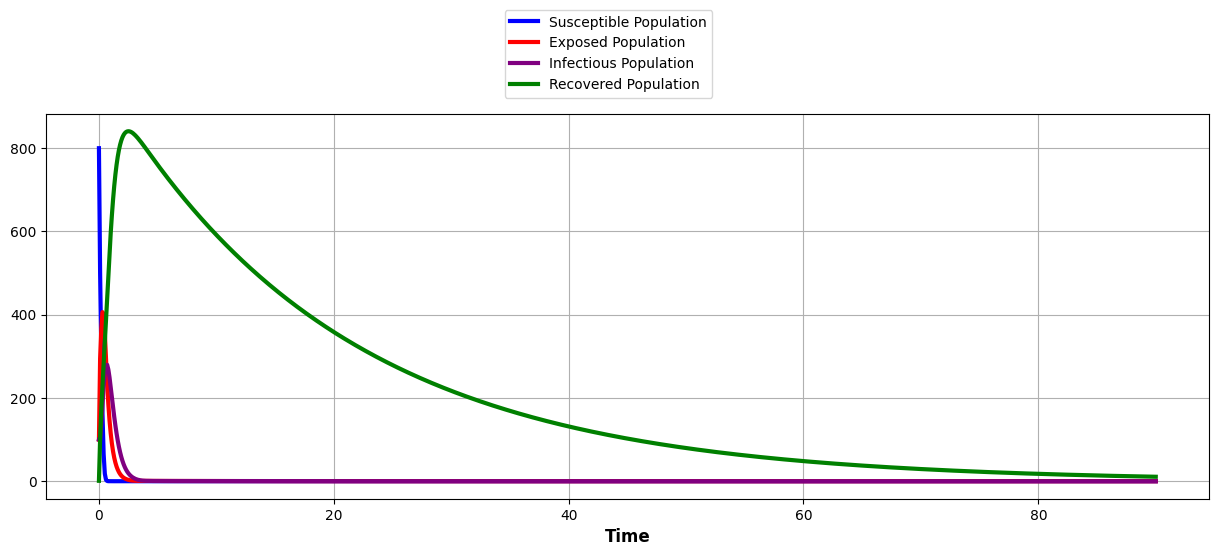

In [ ]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize = (15,5))
plt.plot(t, S1, color = 'blue', ls = '-', label = 'Susceptible Population', linewidth = 3)
plt.plot(t, E1, color = 'red', ls = '-', label = 'Exposed Population', linewidth = 3)
plt.plot(t, I1, color = 'purple', ls = '-', label = 'Infectious Population', linewidth = 3)
plt.plot(t, R1, color = 'green', ls = '-', label = 'Recovered Population', linewidth = 3)
plt.xlabel('Time', fontweight = 'bold', fontsize=12)
plt.legend(bbox_to_anchor=(0.5, 1), loc='center', bbox_transform=plt.gcf().transFigure)
plt.grid()
plt.show()

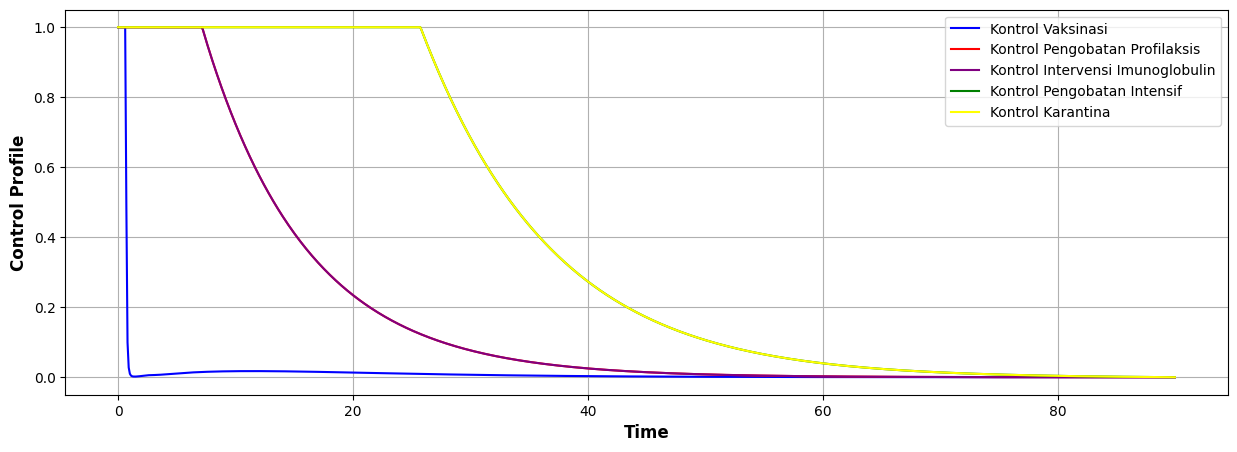

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(t, u1, color='blue', ls='-', label='Kontrol Vaksinasi')
plt.plot(t, u2, color='red', ls='-', label='Kontrol Pengobatan Profilaksis')
plt.plot(t, u3, color='purple', ls='-', label='Kontrol Intervensi Imunoglobulin')
plt.plot(t, u4, color='green', ls='-', label='Kontrol Pengobatan Intensif')
plt.plot(t, u5, color='yellow', ls='-', label='Kontrol Karantina')
plt.xlabel('Time', fontweight='bold', fontsize=12)
plt.ylabel('Control Profile', fontweight='bold', fontsize=12)
plt.legend()
plt.grid()
plt.show()

Perbandingan

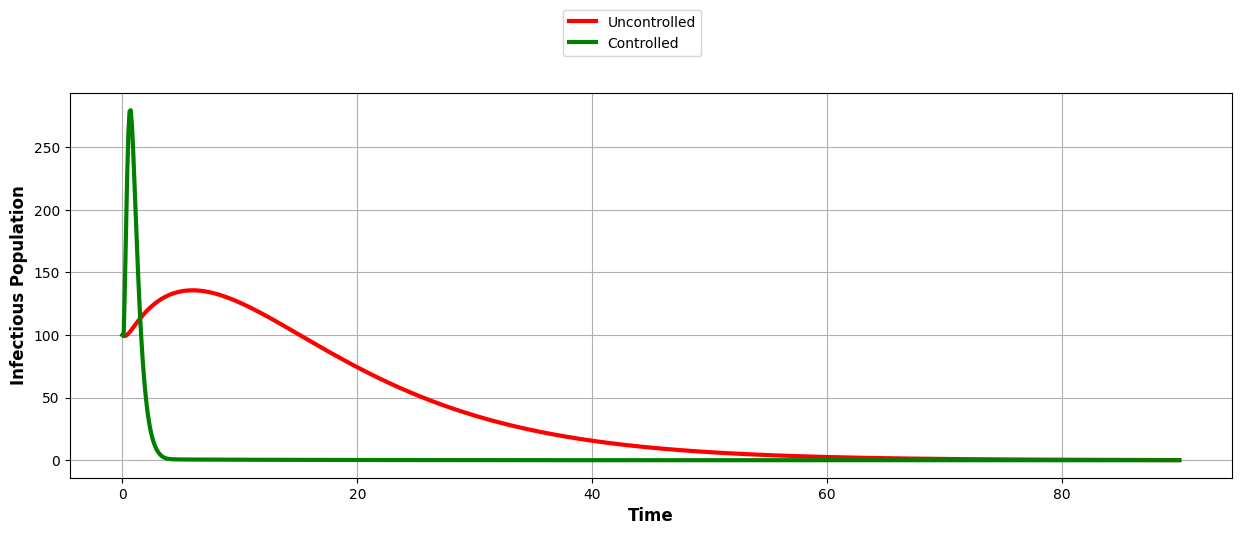

In [ ]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize = (15,5))
plt.plot(t, I0, color = 'red', ls = '-', label = 'Uncontrolled', linewidth = 3)
plt.plot(t, I1, color = 'green', ls = '-', label = 'Controlled', linewidth = 3)
plt.xlabel('Time', fontweight = 'bold', fontsize=12)
plt.ylabel('Infectious Population', fontweight = 'bold', fontsize=12)
plt.legend(bbox_to_anchor=(0.5, 1), loc='center', bbox_transform=plt.gcf().transFigure)
plt.grid()
plt.show()

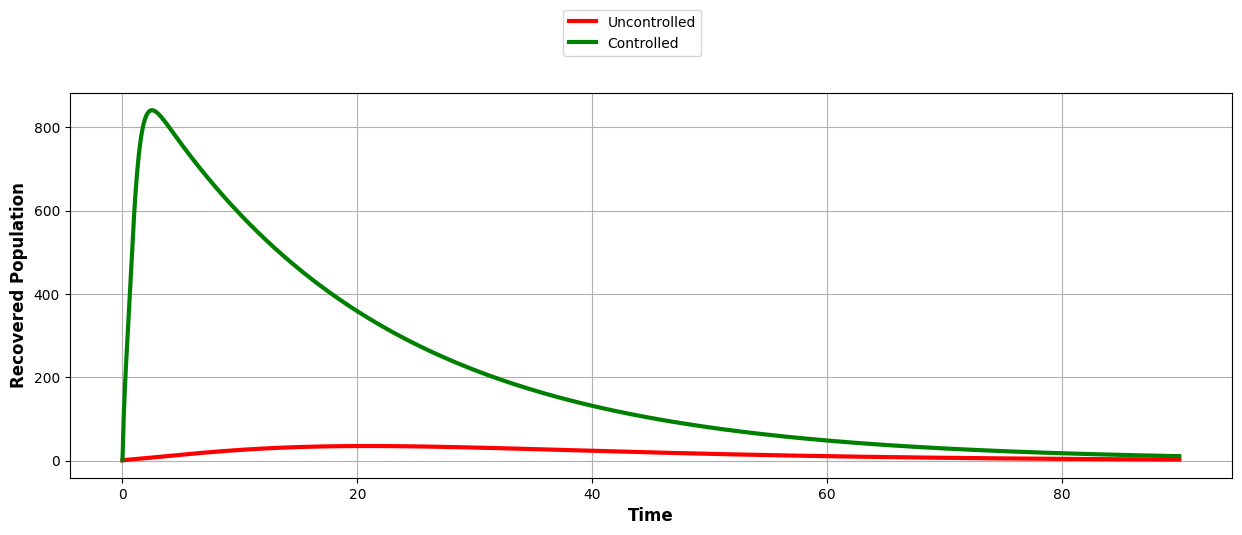

In [ ]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize = (15,5))
plt.plot(t, R0, color = 'red', ls = '-', label = 'Uncontrolled', linewidth = 3)
plt.plot(t, R1, color = 'green', ls = '-', label = 'Controlled', linewidth = 3)
plt.xlabel('Time', fontweight = 'bold', fontsize=12)
plt.ylabel('Recovered Population', fontweight = 'bold', fontsize=12)
plt.legend(bbox_to_anchor=(0.5, 1), loc='center', bbox_transform=plt.gcf().transFigure)
plt.grid()
plt.show()

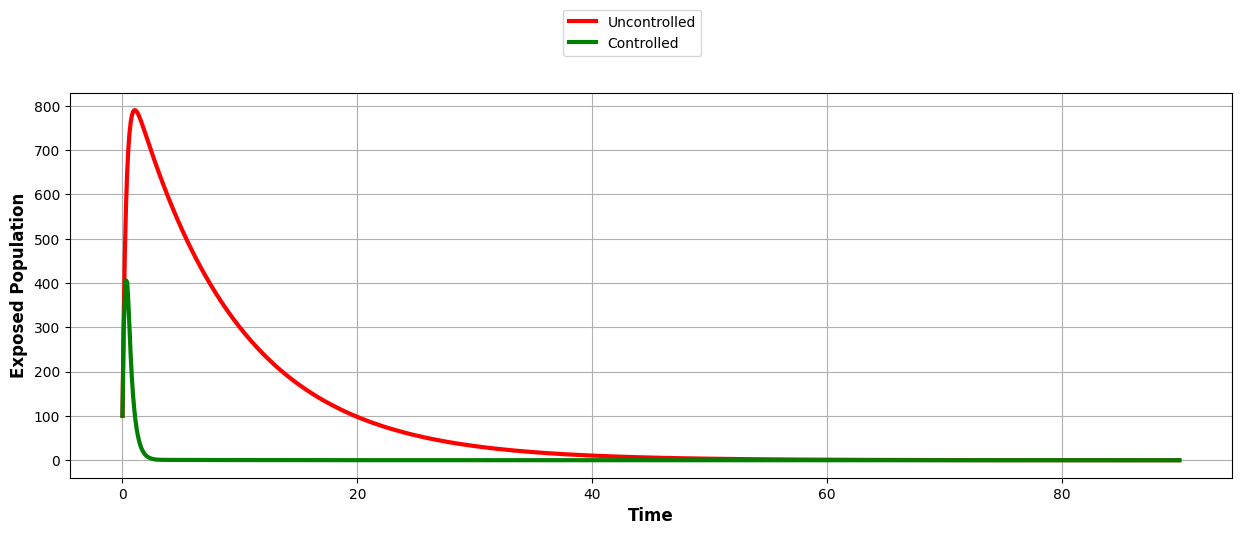

In [ ]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize = (15,5))
plt.plot(t, E0, color = 'red', ls = '-', label = 'Uncontrolled', linewidth = 3)
plt.plot(t, E1, color = 'green', ls = '-', label = 'Controlled', linewidth = 3)
plt.xlabel('Time', fontweight = 'bold', fontsize=12)
plt.ylabel('Exposed Population', fontweight = 'bold', fontsize=12)
plt.legend(bbox_to_anchor=(0.5, 1), loc='center', bbox_transform=plt.gcf().transFigure)
plt.grid()
plt.show()

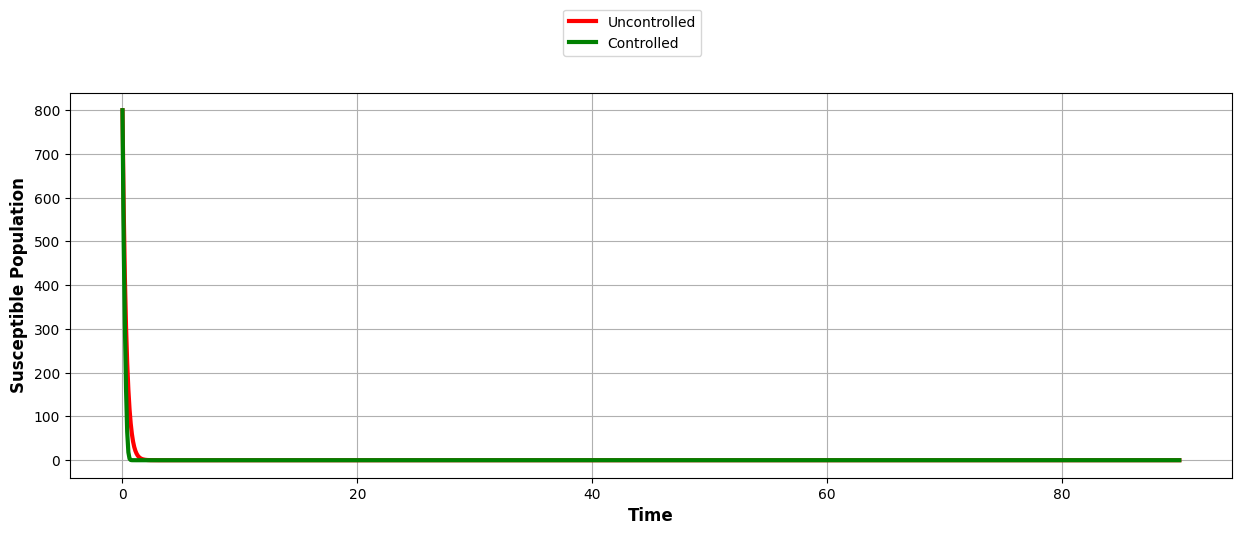

In [ ]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize = (15,5))
plt.plot(t, S0, color = 'red', ls = '-', label = 'Uncontrolled', linewidth = 3)
plt.plot(t, S1, color = 'green', ls = '-', label = 'Controlled', linewidth = 3)
plt.xlabel('Time', fontweight = 'bold', fontsize=12)
plt.ylabel('Susceptible Population', fontweight = 'bold', fontsize=12)
plt.legend(bbox_to_anchor=(0.5, 1), loc='center', bbox_transform=plt.gcf().transFigure)
plt.grid()
plt.show()